In [1]:
# ── 1. KÜTÜPHANELER ───────────────────────────────────────────────────────────

import os
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory

print(f"TensorFlow versiyon : {tf.__version__}")
print(f"GPU'lar             : {tf.config.list_physical_devices('GPU')}")

# ─────────────────────────────────────────────────────────────────────────────


TensorFlow versiyon : 2.10.0
GPU'lar             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:

# ── 2. AYARLAR ────────────────────────────────────────────────────────────────

BASE_DIR    = Path.cwd()
DATA_DIR    = BASE_DIR / "data"
CLASSES     = ["H1", "H2", "H3", "H5", "H6"]
NUM_CLASSES = len(CLASSES)

IMG_SIZE        = (224, 224)
BATCH_SIZE      = 8
EPOCHS_FROZEN   = 10    # Backbone dondurulmuş; sadece head
EPOCHS_FINETUNE = 20    # Tüm ağ açık; ince ayar
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-4

# ────

In [7]:

# ── 3. VERİ YÜKLEYİCİLER ─────────────────────────────────────────────────────
# image_dataset_from_directory klasör adlarını otomatik etiket olarak kullanır.

train_ds = image_dataset_from_directory(
    DATA_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    seed=42,
)

valid_ds = image_dataset_from_directory(
    DATA_DIR / "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    seed=42,
)

test_ds = image_dataset_from_directory(
    DATA_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASSES,
    shuffle=False,
)

# Performans için prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


Found 4780 files belonging to 5 classes.
Found 1022 files belonging to 5 classes.
Found 1029 files belonging to 5 classes.


In [8]:


# ── 4. VERİ ARTIRMA (AUGMENTATION) ───────────────────────────────────────────
# Sadece eğitimde uygulanır; Keras Sequential katman olarak tanımlıyoruz.

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="augmentation")


In [9]:

# ── 5. MODEL — TRANSFER LEARNING (ResNet50) ───────────────────────────────────
# include_top=False → ImageNet sınıflandırma başlığı kaldırılıyor.
# Bizim head'imiz: GlobalAveragePooling → Dropout → Dense(5, softmax)

def build_model(trainable_base=False):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3),
    )
    base.trainable = trainable_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    # ResNet50 kendi ön işlemesini bekler (piksel [0,255] → normalize)
    x = keras.applications.resnet50.preprocess_input(x)
    x = base(x, training=trainable_base)   # BN katmanları için önemli
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return keras.Model(inputs, outputs), base

# ─────────────────────────────────────────────────────────────────────────────


In [10]:

# ── 6. CALLBACK'LER ───────────────────────────────────────────────────────────

def make_callbacks(save_path):
    return [
        keras.callbacks.ModelCheckpoint(
            save_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

# ─────────────────────────────────────────────────────────────────────────────



In [ ]:
# ── 7. AŞAMA 1 — DONUK BACKBONE, SADECE HEAD EĞİTİMİ ────────────────────────

print("\n=== AŞAMA 1: Head Eğitimi (backbone dondurulmuş) ===")

model, base_model = build_model(trainable_base=False)
model.compile(
    optimizer=keras.optimizers.Adam(LR_HEAD),##
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary(show_trainable=True)

history_frozen = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=make_callbacks("best_model_head.keras"),
)

# ─────────────────────────────────────────────────────────────────────────────



=== AŞAMA 1: Head Eğitimi (backbone dondurulmuş) ===
94765736/94765736 [==============================] - 192s 2us/step
Model: "model"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         Y          
                                                                            
 augmentation (Sequential)   (None, 224, 224, 3)       0         Y          
                                                                            
 tf.__operators__.getitem (S  (None, 224, 224, 3)      0         Y          
 licingOpLambda)                                                            
                                                                            
 tf.nn.bias_add (TFOpLambda)  (None, 224, 224, 3)      0         Y          
                                                                            
 resnet50 (Functi

In [12]:

# ── 8. AŞAMA 2 — TÜM AĞ AÇILIYOR (FINE-TUNE) ────────────────────────────────
# Backbone açılıyor; daha küçük LR ile tüm ağ ince ayar yapılıyor.
# Önceki checkpoint'ten yükleyerek devam ediyoruz.

print("\n=== AŞAMA 2: Fine-Tune (tüm ağ açık) ===")

model = keras.models.load_model("best_model_head.keras")

for layer in model.layers:
    layer.trainable = True

# Derlemeyi yenile (trainable değişince zorunlu)
model.compile(
    optimizer=keras.optimizers.Adam(LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_finetune = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=make_callbacks("best_model_resnet.keras"),
)

# ─────────────────────────────────────────────────────────────────────────────



=== AŞAMA 2: Fine-Tune (tüm ağ açık) ===
Epoch 1/20
598/598 [==============================] - ETA: 0s - loss: 1.1145 - accuracy: 0.5469
Epoch 1: val_loss improved from inf to 0.82333, saving model to best_model_resnet.keras
598/598 [==============================] - 101s 154ms/step - loss: 1.1145 - accuracy: 0.5469 - val_loss: 0.8233 - val_accuracy: 0.6575 - lr: 1.0000e-04
Epoch 2/20
598/598 [==============================] - ETA: 0s - loss: 0.9110 - accuracy: 0.6349
Epoch 2: val_loss improved from 0.82333 to 0.79799, saving model to best_model_resnet.keras
598/598 [==============================] - 90s 151ms/step - loss: 0.9110 - accuracy: 0.6349 - val_loss: 0.7980 - val_accuracy: 0.6732 - lr: 1.0000e-04
Epoch 3/20
598/598 [==============================] - ETA: 0s - loss: 0.8040 - accuracy: 0.6713
Epoch 3: val_loss improved from 0.79799 to 0.75970, saving model to best_model_resnet.keras
598/598 [==============================] - 87s 146ms/step - loss: 0.8040 - accuracy: 0.6713 - v

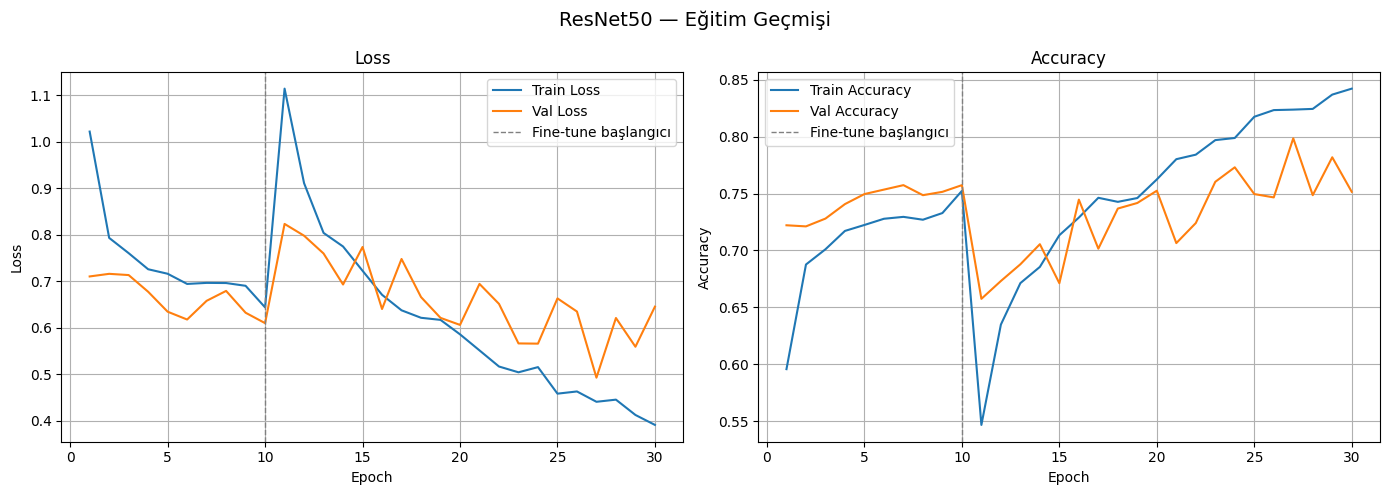

Graf kaydedildi → training_history_resnet.png


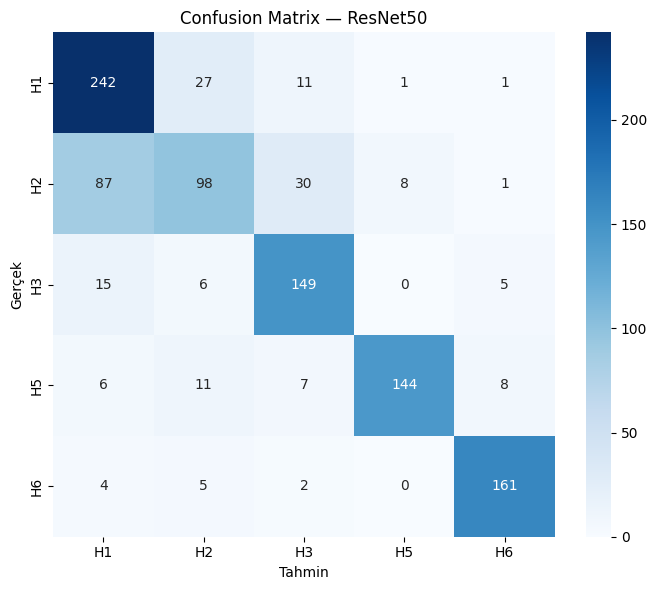

Graf kaydedildi → confusion_matrix_resnet.png

Classification Report:

              precision    recall  f1-score   support

          H1     0.6836    0.8582    0.7610       282
          H2     0.6667    0.4375    0.5283       224
          H3     0.7487    0.8514    0.7968       175
          H5     0.9412    0.8182    0.8754       176
          H6     0.9148    0.9360    0.9253       172

    accuracy                         0.7716      1029
   macro avg     0.7910    0.7803    0.7774      1029
weighted avg     0.7737    0.7716    0.7635      1029



In [14]:

import matplotlib.pyplot as plt

def plot_history(frozen_hist, finetune_hist):
    train_loss = frozen_hist.history["loss"]        + finetune_hist.history["loss"]
    val_loss   = frozen_hist.history["val_loss"]    + finetune_hist.history["val_loss"]
    train_acc  = frozen_hist.history["accuracy"]    + finetune_hist.history["accuracy"]
    val_acc    = frozen_hist.history["val_accuracy"]+ finetune_hist.history["val_accuracy"]

    epochs     = range(1, len(train_loss) + 1)
    frozen_end = len(frozen_hist.history["loss"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, train_loss, label="Train Loss")
    ax1.plot(epochs, val_loss,   label="Val Loss")
    ax1.axvline(frozen_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune başlangıcı")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, train_acc, label="Train Accuracy")
    ax2.plot(epochs, val_acc,   label="Val Accuracy")
    ax2.axvline(frozen_end, color="gray", linestyle="--", linewidth=1, label="Fine-tune başlangıcı")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.suptitle("ResNet50 — Eğitim Geçmişi", fontsize=14)
    plt.tight_layout()
    plt.savefig("training_history_resnet.png", dpi=150)
    plt.show()
    print("Graf kaydedildi → training_history_resnet.png")

plot_history(history_frozen, history_finetune)

# ─────────────────────────────────────────────────────────────────────────────


# ── 11. CONFUSION MATRIX ──────────────────────────────────────────────────────

import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, dataset, class_names):
    y_true, y_pred = [], []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Tahmin")
    ax.set_ylabel("Gerçek")
    ax.set_title("Confusion Matrix — ResNet50")
    plt.tight_layout()
    plt.savefig("confusion_matrix_resnet.png", dpi=150)
    plt.show()
    print("Graf kaydedildi → confusion_matrix_resnet.png")

    return y_true, y_pred

y_true, y_pred = plot_confusion_matrix(best_model, test_ds, CLASSES)

# ─────────────────────────────────────────────────────────────────────────────


# ── 12. CLASSIFICATION REPORT ─────────────────────────────────────────────────

from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
print("\nClassification Report:\n")
print(report)

# ─────────────────────────────────────────────────────────────────────────────


In [13]:
# ── 9. TEST DEĞERLENDİRMESİ ───────────────────────────────────────────────────

print("\n=== Test Değerlendirmesi ===")

best_model = keras.models.load_model("best_model_resnet.keras")
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────



=== Test Değerlendirmesi ===
129/129 [==============================] - 5s 35ms/step - loss: 0.5456 - accuracy: 0.7716

Test Loss    : 0.5456
Test Accuracy: 77.16%
